In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import rasterio
from rasterio.windows import Window
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
filtered_path = os.path.join("../Dataset/filtered_images.csv")
filtered = pd.read_csv(filtered_path)

print("Loaded filtered images:", len(filtered))
filtered.head()

Loaded filtered images: 8015


,image_name,lat,lon,geometry,index_right
0,28.2056_76.8558.png,28.2056,76.8558,POINT (93110.1832241413 3126940.842381583),0
1,28.2056_76.8646.png,28.2056,76.8646,POINT (93975.02981162816 3126911.2561693112),0
2,28.2056_76.8734.png,28.2056,76.8734,POINT (94839.87106457737 3126881.7332521495),23
3,28.2056_76.8822.png,28.2056,76.8822,POINT (95704.70699433371 3126852.2736275145),23
4,28.2056_76.8910.png,28.2056,76.8910,POINT (96569.53761225089 3126822.87729283),23


In [3]:
lc_path = os.path.join("../Data", "worldcover_bbox_delhi_ncr_2021.tif")
lc = rasterio.open(lc_path)

print("CRS:", lc.crs)
print("Resolution:", lc.res)
print("Shape:", (lc.height, lc.width))
vals = np.unique(lc.read(1))
print(vals)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Shape: (9600, 9602)
[ 0 10 20 30 40 50 60 80 90]


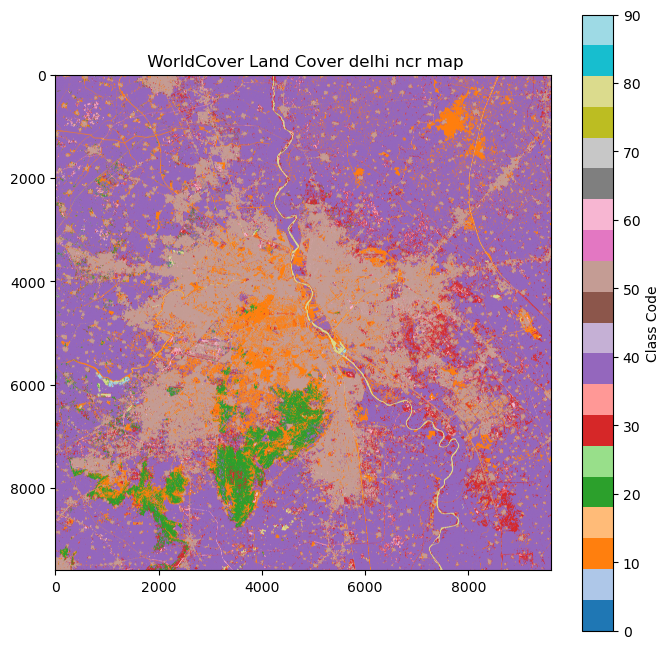

In [4]:
plt.figure(figsize=(8,8))
plt.imshow(lc.read(1), cmap="tab20")
plt.title(" WorldCover Land Cover delhi ncr map")
plt.colorbar(label="Class Code")
plt.savefig("../Visualizations/worldcover_bbox_delhi_ncr_2021.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Extracts a size×size patch centered at (lon, lat)
def extract_landcover_patch(dataset, lon, lat, size=128):

    try:
        # convert lat/lon to raster row, col
        row, col = dataset.index(lon, lat)

        half = size // 2

        window = Window(
            col - half,
            row - half,
            size,
            size
        )

        patch = dataset.read(1, window=window)

        # ensure correct size
        if patch.shape != (size, size):
            return None

        return patch

    except Exception:
        return None

In [30]:
sample = filtered.iloc[0]

patch = extract_landcover_patch(
    lc,
    sample["lon"],
    sample["lat"]
)

print("Patch shape:",  patch.shape)
print("Unique classes:", np.unique(patch))

Patch shape: (128, 128)
Unique classes: [10 20 30 40 50 60]


In [31]:
esa_to_simple = {
    10: "tree",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare",
    70: "Snow",
    80: "Water",
    90: "Wetland",
}

In [32]:
X = []
y = []
valid_rows = []

RGB_DIR = "../Data/rgb"

for idx, row in filtered.iterrows():

    #Load RGB image
    img_path = os.path.join(RGB_DIR, row["image_name"])
    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (128, 128))
    img = img.astype(np.uint8) 
    # img = img / 255.0

    # Extract land-cover patch
    invalid_patch_count = 0
    patch = extract_landcover_patch(
        lc,
        row["lon"],
        row["lat"]
    )

    if patch is None:
        invalid_patch_count += 1
        continue

    # Dominant class
    values, counts = np.unique(patch, return_counts=True)
    dominant_class = values[np.argmax(counts)]

    #Map to simplified label
    label = esa_to_simple.get(dominant_class, "Others")

    #Store
    X.append(img)
    y.append(label)
    valid_rows.append(idx)

print("Invalid patches skipped:", invalid_patch_count)
print("Valid patches used:", len(X))

Invalid patches skipped: 0
Valid patches used: 8015


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X = np.array(X, dtype=np.uint8)
y_encoded = np.array(y_encoded)

print("Classes:", le.classes_)
print("Dataset shape:", X.shape)

Classes: ['Built-up' 'Cropland' 'Grassland' 'Shrubland' 'Water' 'Wetland' 'tree']
Dataset shape: (8015, 128, 128, 3)


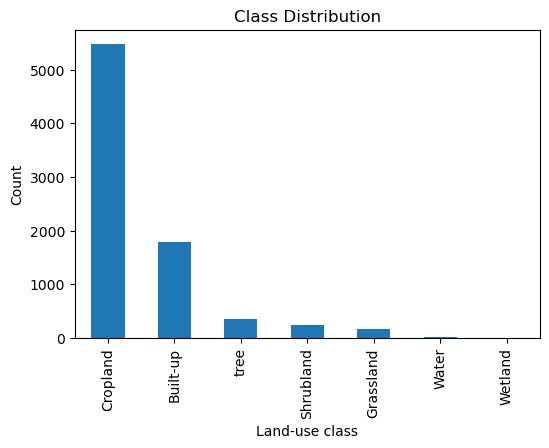

In [34]:
plt.figure(figsize=(6,4))
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xlabel("Land-use class")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.4,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4809
Test size: 3206


In [36]:
SAVE_DIR = "../Dataset/processed"
os.makedirs(SAVE_DIR, exist_ok=True)

In [37]:
np.save(os.path.join(SAVE_DIR, "X_images.npy"), X)
np.save(os.path.join(SAVE_DIR, "y_labels.npy"), y_encoded)

In [38]:
import json

label_map = {i: cls for i, cls in enumerate(le.classes_)}

with open(os.path.join(SAVE_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

print("Label map saved")

Label map saved


In [39]:
np.save(os.path.join(SAVE_DIR, "X_train.npy"), X_train)
np.save(os.path.join(SAVE_DIR, "X_test.npy"), X_test)
np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)

print("Train/test splits saved")

Train/test splits saved
